In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

In [2]:
print("PyTorch Version:", torch.__version__)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using Device:", device)

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

PyTorch Version: 2.7.1+cpu
Using Device: cpu


In [3]:
df = pd.read_csv("NYCTaxiFares.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (120000, 8)


,pickup_datetime,fare_amount,fare_class,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,2010-04-19 08:17:56 UTC,6.5,0,-73.992365,40.730521,-73.975499,40.744746,1
1,2010-04-17 15:43:53 UTC,6.9,0,-73.990078,40.740558,-73.974232,40.744114,1
2,2010-04-17 11:23:26 UTC,10.1,1,-73.994149,40.751118,-73.960064,40.766235,2
3,2010-04-11 21:25:03 UTC,8.9,0,-73.990485,40.756422,-73.971205,40.748192,1
4,2010-04-17 02:19:01 UTC,19.7,1,-73.990976,40.734202,-73.905956,40.743115,1


In [4]:
df.info()

print("\nMissing Values:\n")
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   pickup_datetime    120000 non-null  str    
 1   fare_amount        120000 non-null  float64
 2   fare_class         120000 non-null  int64  
 3   pickup_longitude   120000 non-null  float64
 4   pickup_latitude    120000 non-null  float64
 5   dropoff_longitude  120000 non-null  float64
 6   dropoff_latitude   120000 non-null  float64
 7   passenger_count    120000 non-null  int64  
dtypes: float64(5), int64(2), str(1)
memory usage: 10.0 MB

Missing Values:

pickup_datetime      0
fare_amount          0
fare_class           0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
dtype: int64


In [5]:
df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"])

df["year"] = df["pickup_datetime"].dt.year
df["month"] = df["pickup_datetime"].dt.month
df["day"] = df["pickup_datetime"].dt.day
df["hour"] = df["pickup_datetime"].dt.hour
df["weekday"] = df["pickup_datetime"].dt.weekday

df.drop("pickup_datetime", axis=1, inplace=True)

df.head()

,fare_amount,fare_class,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour,weekday
0,6.5,0,-73.992365,40.730521,-73.975499,40.744746,1,2010,4,19,8,0
1,6.9,0,-73.990078,40.740558,-73.974232,40.744114,1,2010,4,17,15,5
2,10.1,1,-73.994149,40.751118,-73.960064,40.766235,2,2010,4,17,11,5
3,8.9,0,-73.990485,40.756422,-73.971205,40.748192,1,2010,4,11,21,6
4,19.7,1,-73.990976,40.734202,-73.905956,40.743115,1,2010,4,17,2,5


In [6]:
X = df.drop("fare_amount", axis=1)

y = df["fare_amount"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (120000, 11)
Target Shape: (120000,)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(96000, 11)
(24000, 11)


In [8]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train.values,
    dtype=torch.float32
).reshape(-1,1)

y_test_tensor = torch.tensor(
    y_test.values,
    dtype=torch.float32
).reshape(-1,1)

In [10]:
batch_size = 512

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

In [11]:
class TaxiANN(nn.Module):

    def __init__(self, input_features):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(input_features, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)

        )

    def forward(self, x):
        return self.network(x)

In [12]:
input_features = X_train.shape[1]

model = TaxiANN(
    input_features
).to(device)

print(model)

TaxiANN(
  (network): Sequential(
    (0): Linear(in_features=11, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [13]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [14]:
epochs = 30

loss_history = []

start_time = time.time()

for epoch in range(epochs):

    model.train()

    running_loss = 0

    for features, labels in train_loader:

        features = features.to(device)
        labels = labels.to(device)

        predictions = model(features)

        loss = criterion(
            predictions,
            labels
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    loss_history.append(epoch_loss)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Loss: {epoch_loss:.4f}"
    )

end_time = time.time()

training_time = end_time - start_time

print("\nTraining Complete")
print(f"Training Time: {training_time:.2f} seconds")

Epoch [1/30] Loss: 38.3260
Epoch [2/30] Loss: 9.0493
Epoch [3/30] Loss: 7.8789
Epoch [4/30] Loss: 7.4561
Epoch [5/30] Loss: 7.1943
Epoch [6/30] Loss: 7.0252
Epoch [7/30] Loss: 6.8274
Epoch [8/30] Loss: 6.6885
Epoch [9/30] Loss: 6.5606
Epoch [10/30] Loss: 6.4141
Epoch [11/30] Loss: 6.3079
Epoch [12/30] Loss: 6.2057
Epoch [13/30] Loss: 6.1077
Epoch [14/30] Loss: 6.0224
Epoch [15/30] Loss: 5.9180
Epoch [16/30] Loss: 5.8232
Epoch [17/30] Loss: 5.7823
Epoch [18/30] Loss: 5.6784
Epoch [19/30] Loss: 5.6414
Epoch [20/30] Loss: 5.5858
Epoch [21/30] Loss: 5.5164
Epoch [22/30] Loss: 5.5223
Epoch [23/30] Loss: 5.5086
Epoch [24/30] Loss: 5.4923
Epoch [25/30] Loss: 5.4613
Epoch [26/30] Loss: 5.4226
Epoch [27/30] Loss: 5.4027
Epoch [28/30] Loss: 5.4311
Epoch [29/30] Loss: 5.4299
Epoch [30/30] Loss: 5.3484

Training Complete
Training Time: 84.58 seconds


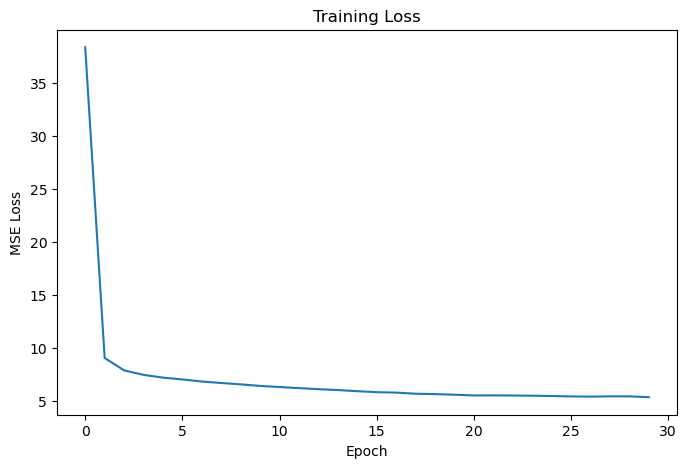

In [15]:
plt.figure(figsize=(8,5))

plt.plot(loss_history)

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.show()

In [16]:
model.eval()

with torch.no_grad():

    predictions = model(
        X_test_tensor.to(device)
    )

predictions = predictions.cpu().numpy()

In [17]:
mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

r2 = r2_score(
    y_test,
    predictions
)

print("MAE :", round(mae,4))
print("RMSE:", round(rmse,4))
print("R²  :", round(r2,4))

MAE : 1.2216
RMSE: 2.3371
R²  : 0.9016


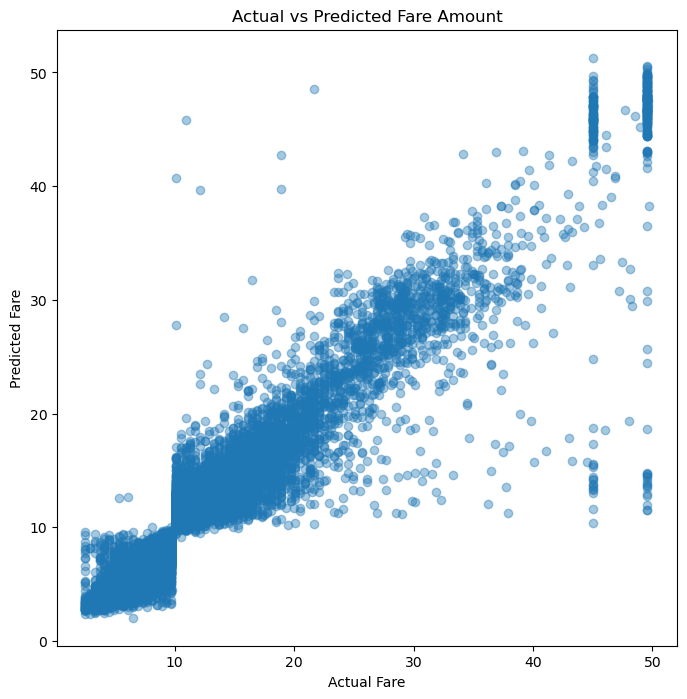

In [18]:
plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    predictions,
    alpha=0.4
)

plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")

plt.title(
    "Actual vs Predicted Fare Amount"
)

plt.show()

In [19]:
print("Device Used:", device)

print(
    f"Training Time: {training_time:.2f} seconds"
)

if device.type == "cuda":

    print("\nGPU acceleration enabled.")

    print(
        "Training benefited from CUDA-based "
        "parallel matrix computations."
    )

else:

    print(
        "\nCPU training only."
    )

Device Used: cpu
Training Time: 84.58 seconds

CPU training only.
